In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

2025-03-13 15:14:28.306066: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/aniketnandi/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import os

In [3]:
os.getcwd()

'/Users/aniketnandi/Desktop/Project 2'

In [4]:
# Load the train dataset
data = pd.read_csv('/Users/aniketnandi/Desktop/Project 2/Sign Language MNIST/sign_mnist_train.csv')
# Load the test dataset
test_data = pd.read_csv('/Users/aniketnandi/Desktop/Project 2/Sign Language MNIST/sign_mnist_test.csv')

/var/folders/66/zbhdwrvx7yv1l277g1q233x80000gn/T/ipykernel_3539/2229945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='viridis')


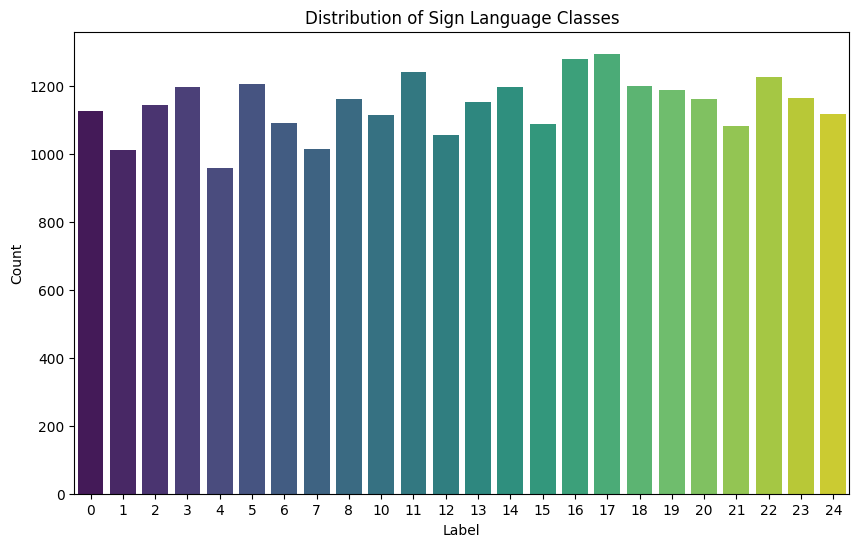

In [5]:
# Chart 1: Distribution of Classes
plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=data, palette='viridis')
plt.title('Distribution of Sign Language Classes')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

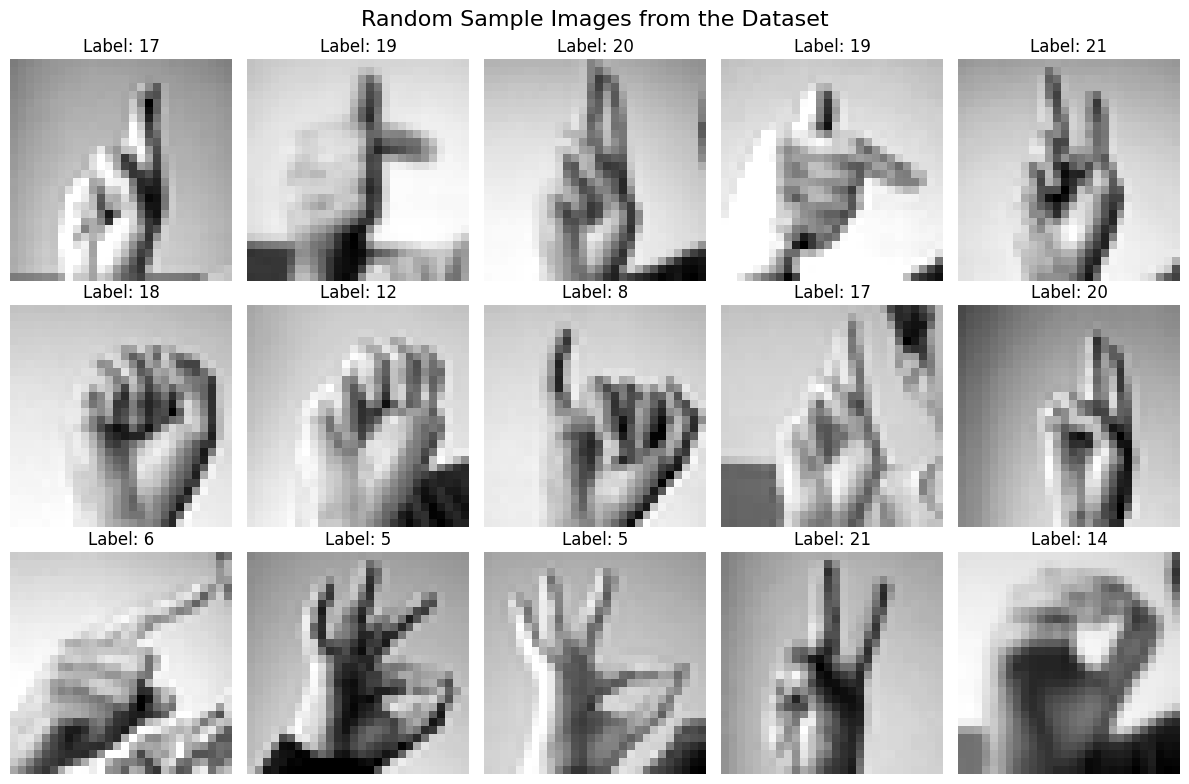

In [6]:
# Chart 2: Sample Images Grid
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Select a random sample
    sample = data.sample(1).iloc[0]
    label = sample['label']
    # Convert pixel columns into a 28x28 image array
    img = sample.drop('label').values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.suptitle('Random Sample Images from the Dataset', fontsize=16)
plt.tight_layout()
plt.show()

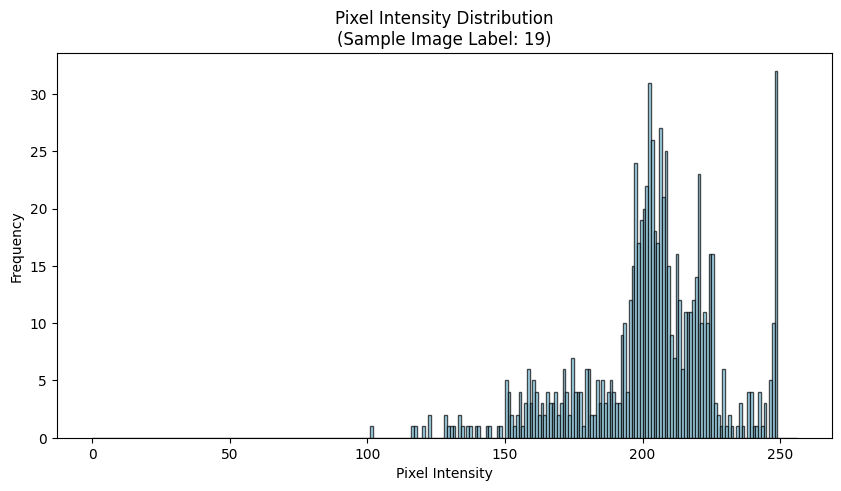

In [7]:
# Chart 3: Pixel Intensity Distribution for a Random Image
# Select a random image
random_idx = np.random.randint(0, len(data))
random_image = data.iloc[random_idx].drop('label').values.astype(np.int32)

plt.figure(figsize=(10, 5))
plt.hist(random_image, bins=range(257), color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Pixel Intensity Distribution\n(Sample Image Label: {data.iloc[random_idx]["label"]})')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

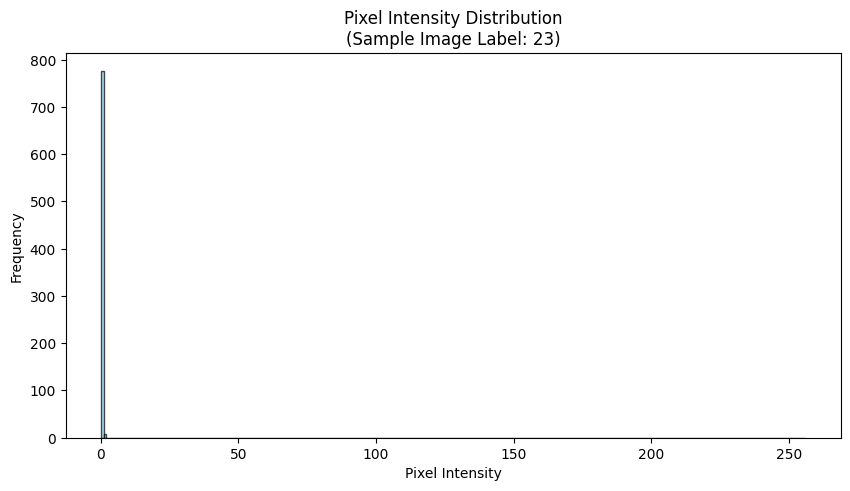

In [8]:
# Separate labels and pixel data
labels = data["label"].values
pixels = data.drop("label", axis=1).values

# Normalize pixel values (scaling from 0 to 1)
pixels_norm = pixels / 255.0

# Reshape the pixel data into images of shape (28, 28, 1)
images = pixels_norm.reshape(-1, 28, 28, 1)

# Select a random image and its corresponding label
rand_idx = np.random.randint(0, len(images))
rand_img = images[rand_idx]
rand_label = labels[rand_idx]

# Plot the histogram of pixel intensities for the random image
plt.figure(figsize=(10, 5))
plt.hist(rand_img.flatten(), bins=range(257), color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Pixel Intensity Distribution\n(Sample Image Label: {rand_label})')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

In [9]:
# Separate features and labels for the train set
X = data.drop('label', axis=1).values
y = data['label'].values
# Separate features and labels for the test set
X_test = test_data.drop('label', axis=1).values
y_test = test_data['label'].values

In [10]:
# Normalize pixel values and reshape to (28, 28, 1) for train set
X = X / 255.0
X = X.reshape(-1, 28, 28, 1)
# Normalize pixel values and reshape to (28, 28, 1) for test set
X_test = X_test / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

In [11]:
# Ensure the number of classes matches (using max label from train and test)
num_classes = max(np.max(y), np.max(y_test)) + 1

In [12]:
# One-hot encode labels for train set
num_classes = np.max(y) + 1
y = to_categorical(y, num_classes)
# One-hot encode labels for test set
y_test = to_categorical(y_test, num_classes)

In [13]:
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)

In [15]:
# Build the CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/Users/aniketnandi/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
# Train the model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=10,
    validation_data=(X_val, y_val)
)

Epoch 1/10


/Users/aniketnandi/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


344/344 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.2286 - loss: 2.6121 - val_accuracy: 0.8372 - val_loss: 0.6301
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.6983 - loss: 0.9522 - val_accuracy: 0.9088 - val_loss: 0.3150
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.8261 - loss: 0.5539 - val_accuracy: 0.9490 - val_loss: 0.1745
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 74ms/step - accuracy: 0.8756 - loss: 0.3867 - val_accuracy: 0.9769 - val_loss: 0.0955
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - accuracy: 0.9097 - loss: 0.2963 - val_accuracy: 0.9916 - val_loss: 0.0546
Epoch 6/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 77ms/step - accuracy: 0.9274 - loss: 0.2345 - val_accuracy: 0.9900 - val_loss: 0.0465
Epoch 7/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.9419 - loss: 0.1870 - val_accuracy: 0.9940 - val_loss: 0.0360
Epoch 8/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.9485 - loss: 0.1636 - val_accurac

In [18]:
# Evaluate the model on validation set
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9996 - loss: 0.0128 
Validation Loss: 0.0129
Validation Accuracy: 0.9995
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9864 - loss: 0.0516
Test Loss: 0.0478
Test Accuracy: 0.9872


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


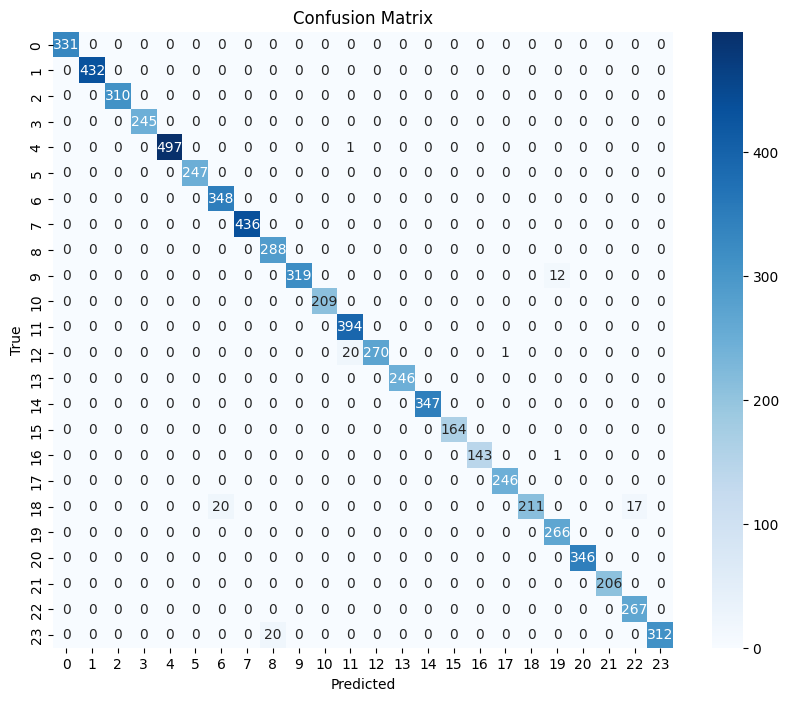

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       310
           3       1.00      1.00      1.00       245
           4       1.00      1.00      1.00       498
           5       1.00      1.00      1.00       247
           6       0.95      1.00      0.97       348
           7       1.00      1.00      1.00       436
           8       0.94      1.00      0.97       288
          10       1.00      0.96      0.98       331
          11       1.00      1.00      1.00       209
          12       0.95      1.00      0.97       394
          13       1.00      0.93      0.96       291
          14       1.00      1.00      1.00       246
          15       1.00      1.00      1.00       347
          16       1.00      1.00      1.00       164
          17       1.00      0.99      1.00       144
          18       1.00    

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Print classification report
print(classification_report(y_true, y_pred_classes))

In [23]:
# Save the trained model
model.save('sign_language_cnn.h5')

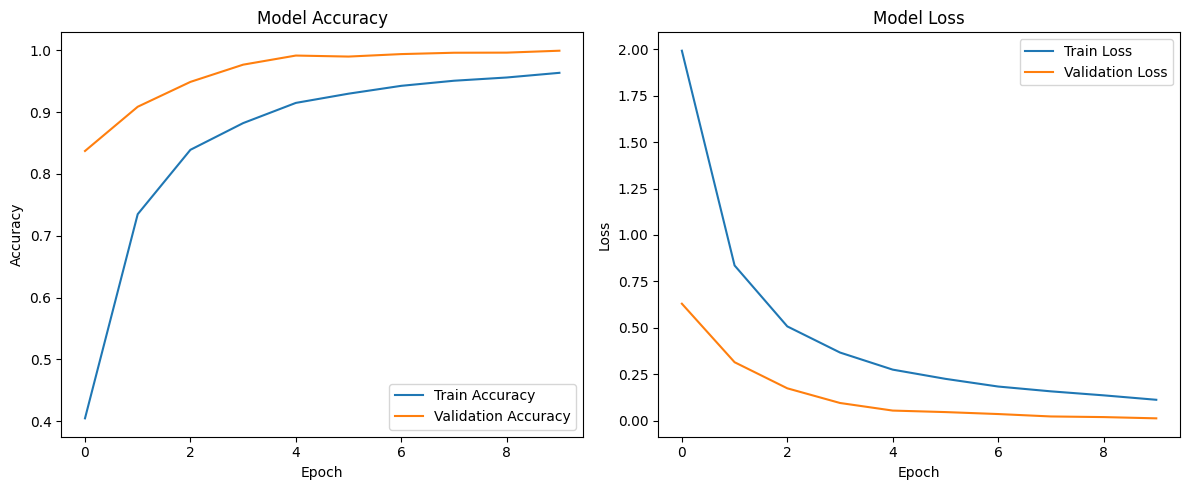

In [24]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()